In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import sklearn
sklearn.set_config(display='text')

식습관 데이터를 차원 축소시켜 시각화 하기

데이터 획득  
사람들의 하루 식습관 데이터를 만든 후 주성분 분석을 사용해서 시각화하기 위해 칼로리, 아침, 점심, 저녁, 운동횟수, 체형이라는 특징을 가지는 데이터프레임을 생성한다.

In [2]:
df = pd.DataFrame(columns = ['calorie', 'breakfast', 'lunch', 'dinner', 'exercise', 'body_shape'])
df.loc[0] = [1200, 1, 0, 0, 2, 'Skinny']
df.loc[1] = [2800, 1, 1, 1, 1, 'Normal']
df.loc[2] = [3500, 2, 2, 1, 0, 'Fat']
df.loc[3] = [1400, 0, 1, 0, 3, 'Skinny']
df.loc[4] = [5000, 2, 2, 2, 0, 'Fat']
df.loc[5] = [1300, 0, 0, 1, 2, 'Skinny']
df.loc[6] = [3000, 1, 0, 1, 1, 'Normal']
df.loc[7] = [4000, 2, 2, 2, 0, 'Fat']
df.loc[8] = [2600, 0, 2, 0, 0, 'Normal']
df.loc[9] = [3000, 1, 2, 1, 1, 'Fat']
df

,calorie,breakfast,lunch,dinner,exercise,body_shape
0,1200,1,0,0,2,Skinny
1,2800,1,1,1,1,Normal
2,3500,2,2,1,0,Fat
3,1400,0,1,0,3,Skinny
4,5000,2,2,2,0,Fat
5,1300,0,0,1,2,Skinny
6,3000,1,0,1,1,Normal
7,4000,2,2,2,0,Fat
8,2600,0,2,0,0,Normal
9,3000,1,2,1,1,Fat


데이터 전처리 과정을 통해서 데이터 범위가 제각각인 특징을 표준화(정규화) 한다.

위의 데이터는 칼로리가 유난히 다른 특성들에 비해 수치 범위가 큰 것을 확인할 수 있다. 수치가 큰 칼로리와 다른 특성들은 눈으로 비교할 수 없듯이 머신러닝 모델 비교하기 힘들어진다.  
이 경우 모든 특성들이 평균이 0이고 분산이 1인 데이터로 변환한 후 비교하면 특성들의 상관 관계를 이해하기 쉬워지고 머신러닝 모델 역시 더욱 효율적으로 데이터를 학습할 수 있다.

피쳐 분리하기

In [3]:
# 데이터에 피쳐와 레이블이 함께있으므로 피쳐로만 구성된 데이터프레임을 만든다.
x = df[['calorie', 'breakfast', 'lunch', 'dinner', 'exercise']]
x

,calorie,breakfast,lunch,dinner,exercise
0,1200,1,0,0,2
1,2800,1,1,1,1
2,3500,2,2,1,0
3,1400,0,1,0,3
4,5000,2,2,2,0
5,1300,0,0,1,2
6,3000,1,0,1,1
7,4000,2,2,2,0
8,2600,0,2,0,0
9,3000,1,2,1,1


In [4]:
# 평균이 0이고 분산이 1인 데이터로 표준화(정규화)를 하기 위해 import 한다.
from sklearn.preprocessing import StandardScaler

방법1  
`ss = StandardScaler()`: 모델을 만든다.  
`x_train = ss.fit(x)`: 모델을 학습시킨다.  
`x_train = ss.transform(x)`: 학습된 결과를 적용한다.

방법2  
`ss = StandardScaler()`: 모델을 만든다.  
`x_train = ss.fit_transform(x)`: 모델 학습시키고 학습된 결과를 적용한다.

In [5]:
# 칼로리를 포함한 모든 특성들을 같은 범위로 표준화 한다.
x_train = StandardScaler().fit_transform(x)
print(x_train)

[[-1.35205803  0.         -1.3764944  -1.28571429  1.        ]
 [ 0.01711466  0.         -0.22941573  0.14285714  0.        ]
 [ 0.61612771  1.29099445  0.91766294  0.14285714 -1.        ]
 [-1.18091145 -1.29099445 -0.22941573 -1.28571429  2.        ]
 [ 1.89972711  1.29099445  0.91766294  1.57142857 -1.        ]
 [-1.26648474 -1.29099445 -1.3764944   0.14285714  1.        ]
 [ 0.18826125  0.         -1.3764944   0.14285714  0.        ]
 [ 1.04399418  1.29099445  0.91766294  1.57142857 -1.        ]
 [-0.15403193 -1.29099445  0.91766294 -1.28571429 -1.        ]
 [ 0.18826125  0.          0.91766294  0.14285714  0.        ]]


레이블 분리하기

In [6]:
y_train = df[['body_shape']]
y_train

,body_shape
0,Skinny
1,Normal
2,Fat
3,Skinny
4,Fat
5,Skinny
6,Normal
7,Fat
8,Normal
9,Fat


공분산 행렬 구하기

주성분 분석을 하기위해서 가장 먼저 할 일은 특징들의 공분산 행렬을 구하는 것이다.

In [8]:
# numpy의 cov() 메소드로 공분산 행렬을 계산할 수 있다.
cov_mat = np.cov(x_train.T)
cov_mat

array([[ 1.11111111,  0.88379717,  0.76782385,  0.89376551, -0.93179808],
       [ 0.88379717,  1.11111111,  0.49362406,  0.81967902, -0.71721914],
       [ 0.76782385,  0.49362406,  1.11111111,  0.40056715, -0.76471911],
       [ 0.89376551,  0.81967902,  0.40056715,  1.11111111, -0.63492063],
       [-0.93179808, -0.71721914, -0.76471911, -0.63492063,  1.11111111]])

고유값과 고유 벡터 구하기

공분산 행렬에서 가장 큰 고유값을 가진 고유 벡터를 찾아 그 벡터위에 사영시킨다. 사영시킨다는 의미는 데이터 손실을 최소한으로 하는 고차원 공간을 저차원으로 축소한다는 의미이다.

In [11]:
# 공분산 행렬에서 고유값과 고유 벡터를 계산한다.
las, evs = np.linalg.eig(cov_mat)
print('고유값\n', las, sep='')
print('고유 벡터\n', evs, sep='')

고유값
[4.0657343  0.8387565  0.07629538 0.27758568 0.2971837 ]
고유 벡터
[[-0.508005   -0.0169937  -0.84711404  0.11637853  0.10244985]
 [-0.44660335 -0.36890361  0.12808055 -0.63112016 -0.49973822]
 [-0.38377913  0.70804084  0.20681005 -0.40305226  0.38232213]
 [-0.42845209 -0.53194699  0.3694462   0.22228235  0.58954327]
 [ 0.46002038 -0.2816592  -0.29450345 -0.61341895  0.49601841]]


In [12]:
# 각각의 고유 벡터로 데이터를 사영할 경우 얼마 만큼의 정보가 유지되는지 확인한다.
for i in range(len(las)):
    print(las[i] / sum(las))

0.7318321731427544
0.15097617056715096
0.013733167936950065
0.04996542317586186
0.05349306517728265


위의 결과를 통해 1차원 데이터로 차원 축소를 하더라도 73.2% 정도에 해당되는 정보를 유지할 수 있다는 사실을 확인할 수 있고 26.8% 정도의 정보 손실은 감수하고 1차원 데이터로 축소한다.

In [15]:
proj = x_train.dot(evs.T[0] / np.linalg.norm(evs.T[0]))
print(proj)

[ 2.22600943  0.0181432  -1.76296611  2.73542407 -3.02711544  2.14702579
  0.37142473 -2.59239883  0.39347815 -0.50902498]


시각화

데이터가 사용된 고유 벡터(주성분)를 x축으로 하고 1차원 데이터이므로 y축은 0으로 고정시킨다.

In [19]:
result = pd.DataFrame(proj, columns=['x'])
result['y'] = 0.0
result['label'] = y_train
result

,x,y,label
0,2.226009,0.0,Skinny
1,0.018143,0.0,Normal
2,-1.762966,0.0,Fat
3,2.735424,0.0,Skinny
4,-3.027115,0.0,Fat
5,2.147026,0.0,Skinny
6,0.371425,0.0,Normal
7,-2.592399,0.0,Fat
8,0.393478,0.0,Normal
9,-0.509025,0.0,Fat


<Figure size 800x600 with 0 Axes>

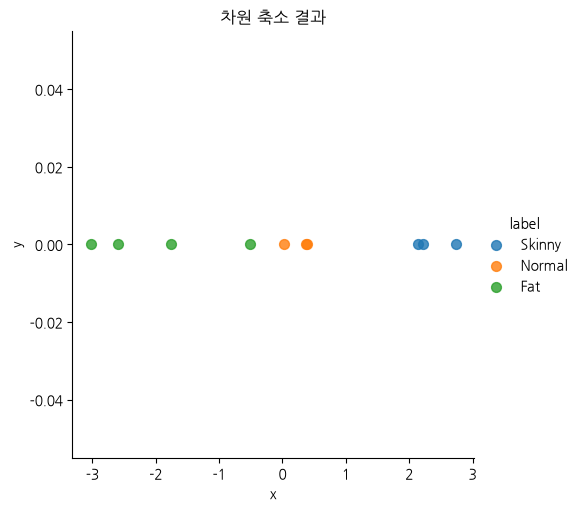

In [31]:
plt.figure(figsize=(8, 6))
sns.lmplot(data=result, x='x', y='y', fit_reg=False, hue='label', scatter_kws={'s': 50})
plt.title('차원 축소 결과')
plt.show()

사이킷런을 이용한 주성분 분석 구현

사이킷런을 라이브러리를 사용하면 단 몇 줄만으로 간단하게 구현할 수 있다. 다음과 같이 주성분 분석 라이브러리를 사용해서 5차원 데이터를 1차원으로 아주 간단히 축소할 수 있다.

In [32]:
# 사이킷런에서 주성분 분석을 하기 위해 import 한다.
from sklearn.decomposition import PCA

In [33]:
# PCA 모델 객체를 만들 때 n_components 하이퍼파라미터 옵션으로 축소하려는 차원의 크기를 지정한다.
model = PCA(n_components=1).fit_transform(x_train)
model

array([[-2.22600943],
       [-0.0181432 ],
       [ 1.76296611],
       [-2.73542407],
       [ 3.02711544],
       [-2.14702579],
       [-0.37142473],
       [ 2.59239883],
       [-0.39347815],
       [ 0.50902498]])

In [34]:
result = pd.DataFrame(model, columns=['x'])
result['y'] = 0.0
result['label'] = y_train
result

,x,y,label
0,-2.226009,0.0,Skinny
1,-0.018143,0.0,Normal
2,1.762966,0.0,Fat
3,-2.735424,0.0,Skinny
4,3.027115,0.0,Fat
5,-2.147026,0.0,Skinny
6,-0.371425,0.0,Normal
7,2.592399,0.0,Fat
8,-0.393478,0.0,Normal
9,0.509025,0.0,Fat


<Figure size 800x600 with 0 Axes>

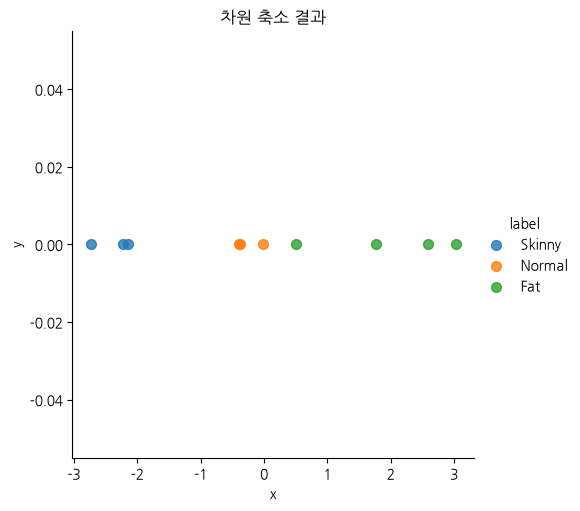

In [35]:
plt.figure(figsize=(8, 6))
sns.lmplot(data=result, x='x', y='y', fit_reg=False, hue='label', scatter_kws={'s': 50})
plt.title('차원 축소 결과')
plt.show()